# Lab 7: Word Sequences

##### Autors: Josep de Cid & Gonzalo Recio

Requirements and imports

In [17]:
# !pip3 install tkinter

In [18]:
import nltk
nltk.download('maxent_ne_chunker')
nltk.download('conll2000')

from nltk import word_tokenize, pos_tag, ne_chunk
from scipy.stats import pearsonr
import termtables as tt

[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /home/gonzalo/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     /home/gonzalo/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!


First we read the dataset into a list of pairs containing the sentences *[(A1, B1), ..., (An, Bn)]*

In [19]:
sentences = []

with open('trial/STS.input.txt', mode='r') as f:
    for idx, line in enumerate(f.readlines()):
        _, a, b = line.strip().split('\t')
        sentences.append([a, b])
        
        print(f'{idx + 1}a) {a}')
        print(f'{idx + 1}b) {b}\n')

1a) The bird is bathing in the sink.
1b) Birdie is washing itself in the water basin.

2a) In May 2010, the troops attempted to invade Kabul.
2b) The US army invaded Kabul on May 7th last year, 2010.

3a) John said he is considered a witness but not a suspect.
3b) "He is not a suspect anymore." John said.

4a) They flew out of the nest in groups.
4b) They flew into the nest together.

5a) The woman is playing the violin.
5b) The young lady enjoys listening to the guitar.

6a) John went horse back riding at dawn with a whole group of friends.
6b) Sunrise at dawn is a magnificent view to take in if you wake up early enough for it.



### NE Chunk exploration

The following code shows how NE chunk from nltk works

(S
  (NE John/NNP Smith/NNP)
  is/VBZ
  working/VBG
  in/IN
  (NE United/NNP States/NNPS))


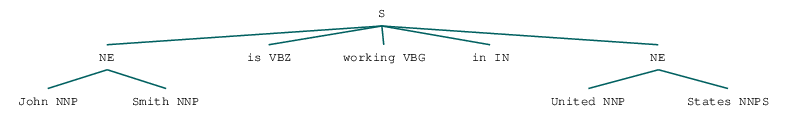

In [20]:
sentence = 'John Smith is working in United States' #sentences[1][1]
pos = pos_tag(word_tokenize(sentence))
res = ne_chunk(pos, binary=True)  # binary: True for recognizing NEs

# print(nltk.chunk.tree2conllstr(res))
# print(nltk.chunk.tree2conlltags(res))
print(res)
res

In order to extract NE as one word token (all together) from the grammar tree, it can be performed as follows:

In [21]:
result = []
for chunk in res:
    if hasattr(chunk, 'label'):
        result.append(' '.join(c[0] for c in chunk))
    else:
        result.append(chunk[0])
result

['John Smith', 'is', 'working', 'in', 'United States']

### Implementation

The following function `get_words_and_NEs` converts a given sentence into a set of **words + Named Entities**

In [22]:
def get_words_and_NEs(sentence):
    # Find NEs
    x = pos_tag(word_tokenize(sentence))
    tree = ne_chunk(x, binary=True)  # binary: True for recognizing NEs
    
    result = []
    for chunk in tree:
        if hasattr(chunk, 'label'):
            result.append(' '.join(c[0] for c in chunk))
        else:
            result.append(chunk[0])
    return result, tree

We will see an example of how this function works. For instance, the sentence `John Smith is working in United States` should be converted to a set of *words + Named Entities* in this way: `['John Smith', 'is', 'working', 'in', 'United States']`. Observe that `"John Smith"` and `"United States"` are NE and need to be together as a single word.

Original tokenized sentence:	 ['John', 'Smith', 'is', 'working', 'in', 'United', 'States']
Words + NEs:			 ['John Smith', 'is', 'working', 'in', 'United States']


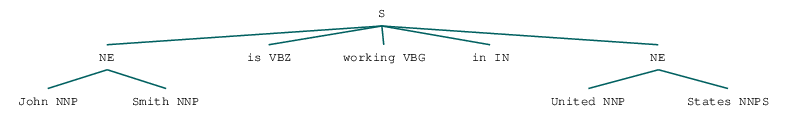

In [23]:
sentence = 'John Smith is working in United States' 
print('Original tokenized sentence:\t', nltk.word_tokenize(sentence))

words_and_NEs, tree = get_words_and_NEs(sentence)
print('Words + NEs:\t\t\t', words_and_NEs)
tree

We observe that the previous function performs well and outputs 'John Smith' and 'United States' alltogether as Named Entities as we expected.

## Jaccard Distance

Now let's compute Jaccard distance coefficient between sentences with the set of *words + NEs*.

In [24]:
from nltk.metrics import jaccard_distance

distances = []
distances_NE = []

for s1, s2 in sentences:
    words_NEs_1, _ = get_words_and_NEs(s1)
    words_NEs_2, _ = get_words_and_NEs(s2)
    
    dist    = jaccard_distance(set(nltk.word_tokenize(s1)), set(nltk.word_tokenize(s2)))
    dist_NE = jaccard_distance(set(words_NEs_1), set(words_NEs_2))
    
    distances.append(dist)
    distances_NE.append(dist_NE)

# print(distances)
# print(distances_NE)

Show Jaccard coefficient results:

In [25]:
print(tt.to_string(
        data=[['Jaccand dists. (only words)']+[f'{x:.5}'for x in distances],
              ['Jaccard dists. (with words+NE)']+[f'{x:.5}'for x in distances_NE]],
        header=[' ', 'pair 1', 'pair 2','pair 3','pair 4','pair 5','pair 6']
            
))

┌────────────────────────────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┐
│                                │ pair 1  │ pair 2  │ pair 3  │ pair 4  │ pair 5  │ pair 6  │
╞════════════════════════════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╡
│ Jaccand dists. (only words)    │ 0.69231 │ 0.73684 │ 0.53333 │ 0.54545 │ 0.76923 │ 0.86207 │
├────────────────────────────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│ Jaccard dists. (with words+NE) │ 0.69231 │ 0.73684 │ 0.53333 │ 0.54545 │ 0.76923 │ 0.86207 │
└────────────────────────────────┴─────────┴─────────┴─────────┴─────────┴─────────┴─────────┘


We can see that for this small trial dataset there there are **no improvements** than using simple Jaccard distance using sentence tokens (like in Session 2).

# (Optional): Extending the grammar

New presented grammar detects Noun Phrases (NP). For example, it detects `"the nice yellow dog"` as a NP all together.

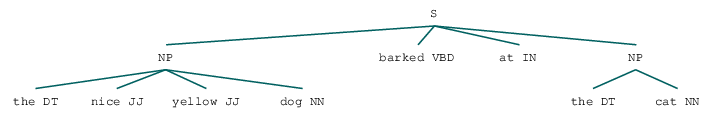

In [26]:
import nltk

sentence = [("the", "DT"), ("nice", "JJ"), ("yellow", "JJ"),("dog", "NN"),\
            ("barked", "VBD"), ("at", "IN"), ("the", "DT"), ("cat", "NN")]


grammar = "NP: {<DT>?<JJ>*<NN>}"  # extended grammar

cp = nltk.RegexpParser(grammar)
tree = cp.parse(sentence)
tree


We need to rewrite the detection function to extend the previous grammar with the new one:

In [27]:
def get_words_and_NEs_extended(sentence):
    x = pos_tag(word_tokenize(sentence))
    x = ne_chunk(x, binary=True)

    grammar = "NP: {<DT>?<JJ>*<NN>}"  # extended grammar

    cp = nltk.RegexpParser(grammar)
    tree = cp.parse(x)
    # print(tree)
    
    result = []
    for chunk in tree:
        if hasattr(chunk, 'label'):
            result.append(' '.join(c[0] for c in chunk))
        else:
            result.append(chunk[0])

    return result, tree


With the previous grammar we only detected and extracted NEs, but now we want to extract Noun Phrases (NP) as well as a single entity.

Previous grammar did not detect NP, as we can see with the following example (with `"the nice yellow dog"`):

Result with previous grammar:
 ['John Smith', 'works', 'with', 'the', 'nice', 'yellow', 'dog', 'in', 'United States']


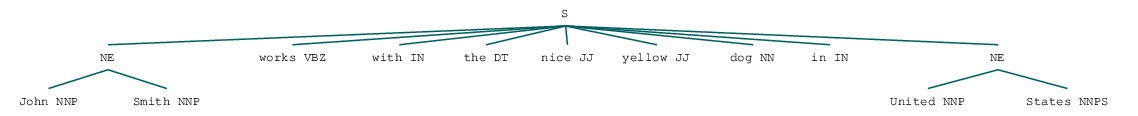

In [28]:
sentence = 'John Smith works with the nice yellow dog in United States' 

# With previous grammar
words_NEs, tree = get_words_and_NEs(sentence)
print('Result with previous grammar:\n', words_NEs)
tree


With new grammar (joining both), we obtain the desired sentence transformation:

Result with extended grammar:
 ['John Smith', 'works', 'with', 'the nice yellow dog', 'in', 'United States']


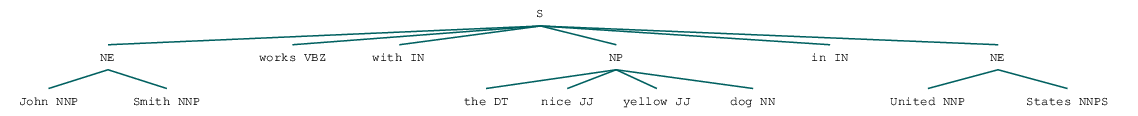

In [29]:
sentence = 'John Smith works with the nice yellow dog in United States' 

# With extended grammar
words_NEs_ext, tree = get_words_and_NEs_extended(sentence)
print('Result with extended grammar:\n', words_NEs_ext)
tree

Now, NEs and NPs are both detected and extracted. Note that `John Smith`, `the nice yellow dog` and `United States` are all extracted as a one.

# Conclusions


In this small trial dataset we did not see any improvements for computing sentence similarity using Named Entities as a one. However, it makes a lot of sense to work with Named Entities as one word. An example of that whould be between like these:
   - "United people achieve goals better."
   - "James Smith is working in United States."

Both sentences share a common word `"United"` but in the second sentences it belongs to a Named Entity and the meaning is completely different. Using only words would lead to less distance, but the 2 sentences have null similarity in common.

The example below inlustrates this improvements using words+NE rather only words. 

In [30]:
s1 = "United people achieve goals better."
s2 = "James Smith is working in United States."

words_NEs_1, _ = get_words_and_NEs(s1)
words_NEs_2, _ = get_words_and_NEs(s2)

dist    = jaccard_distance(set(nltk.word_tokenize(s1)), set(nltk.word_tokenize(s2)))
dist_NE = jaccard_distance(set(words_NEs_1), set(words_NEs_2))

print('Distance (only words):', f'{dist:.5}')
print('Distance (words+NE):  ', f'{dist_NE:.5}',  '<-- we get higher distance so NER here helps significantly')


Distance (only words): 0.83333
Distance (words+NE):   0.90909 <-- we get higher distance so NER here helps significantly


A drawback of using Names Entities as a one, it would be that some Named Entities can be written in different ways, for instance "United States" and "USA" or "James Smith" and "Mr Smith". Hence, using NEs can worsen in some cases the distance coefficient, specially on people names ("John Smith", "Mr. Smith", "Dr. Smith", all refer to the same entity). For solving this, it would be needed to perform something like Named Entity Coreference Resolution.